# 04 Evaluation: SHAP explainability analysis

This notebook explains the selected model with SHAP (SHapley Additive exPlanations).
A SHAP value is the amount one input moved one water point's predicted probability away from the average prediction.
Positive values push towards a class, negative values push away from it.

Sections: (1) global importance, (2) direction of effects for Non-Functional, (3) two local explanations,
(4) counterfactuals, (5) what this means for FundiFix.

In [1]:
# Run from the repo root folder, or this cell moves there for you
import os, sys
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, str(Path.cwd()))
os.environ["MLFLOW_DISABLE_AGENT_HINT"] = "1"
import warnings; warnings.filterwarnings("ignore")

In [2]:
import joblib, json, numpy as np, pandas as pd
from src.models.config import FEATURES, MODEL_PATH, RANDOM_STATE, CLASSES
from src.models.data import load_modelling_data, split
from src.models import explain
model = joblib.load(MODEL_PATH)
train, test = split(load_modelling_data("mixed"))
sample = test.sample(n=600, random_state=RANDOM_STATE).reset_index(drop=True)
sv, X_t = explain.shap_values(model, sample[FEATURES])
print(f"SHAP values for {len(sample)} test water points, {X_t.shape[1]} model inputs, {len(CLASSES)} classes")

SHAP values for 600 test water points, 41 model inputs, 3 classes


## 1. Global importance
Mean absolute SHAP value per input, one-hot columns combined back into the original field.

In [3]:
g = explain.global_importance(sv, list(X_t.columns))
g.index = [explain.LABELS.get(i, i) for i in g.index]
g.round(3)

,Functional,Needs Repair,Non-Functional,all_classes
Pump / technology type,0.067,0.082,0.036,0.185
Water source type,0.049,0.061,0.074,0.183
Distance to primary road,0.038,0.039,0.015,0.092
Age at report (years),0.030,0.021,0.013,0.064
Distance to town,0.022,0.017,0.023,0.062
Distance to city,0.022,0.018,0.018,0.058
Distance to secondary road,0.020,0.023,0.014,0.057
Population within 1 km,0.018,0.010,0.014,0.042
Criticality score,0.015,0.011,0.015,0.041
Management type,0.016,0.011,0.011,0.038


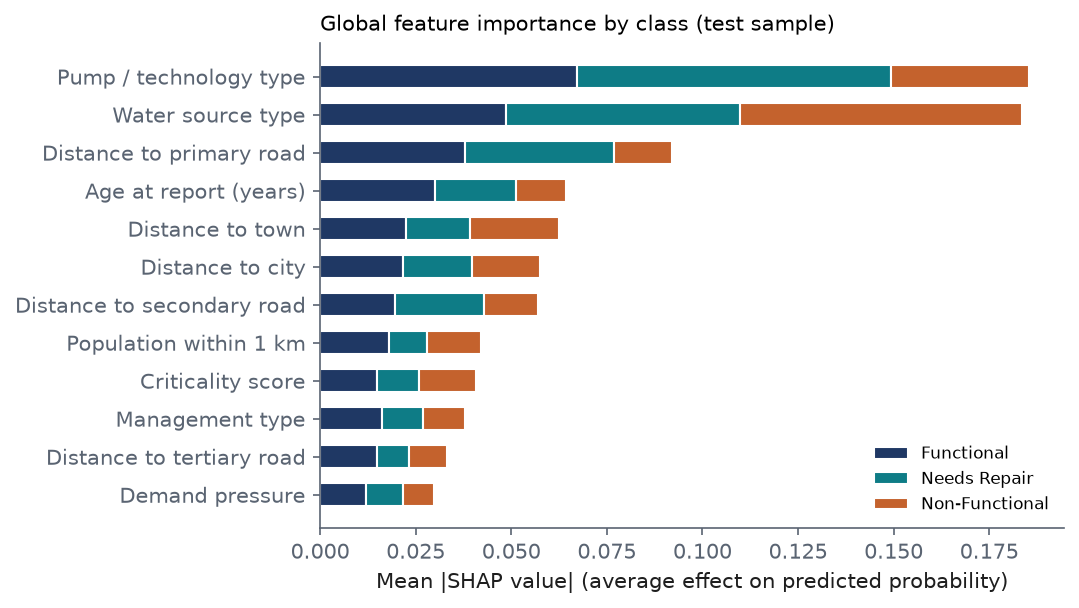

In [4]:
explain.plot_global(explain.global_importance(sv, list(X_t.columns)), "reports/figures/shap_global_importance.png")
from IPython.display import Image, display
display(Image("reports/figures/shap_global_importance.png"))

## 2. Direction of effects on the Non-Functional probability
Each dot is one water point. Red means a high value of that input, blue a low value.

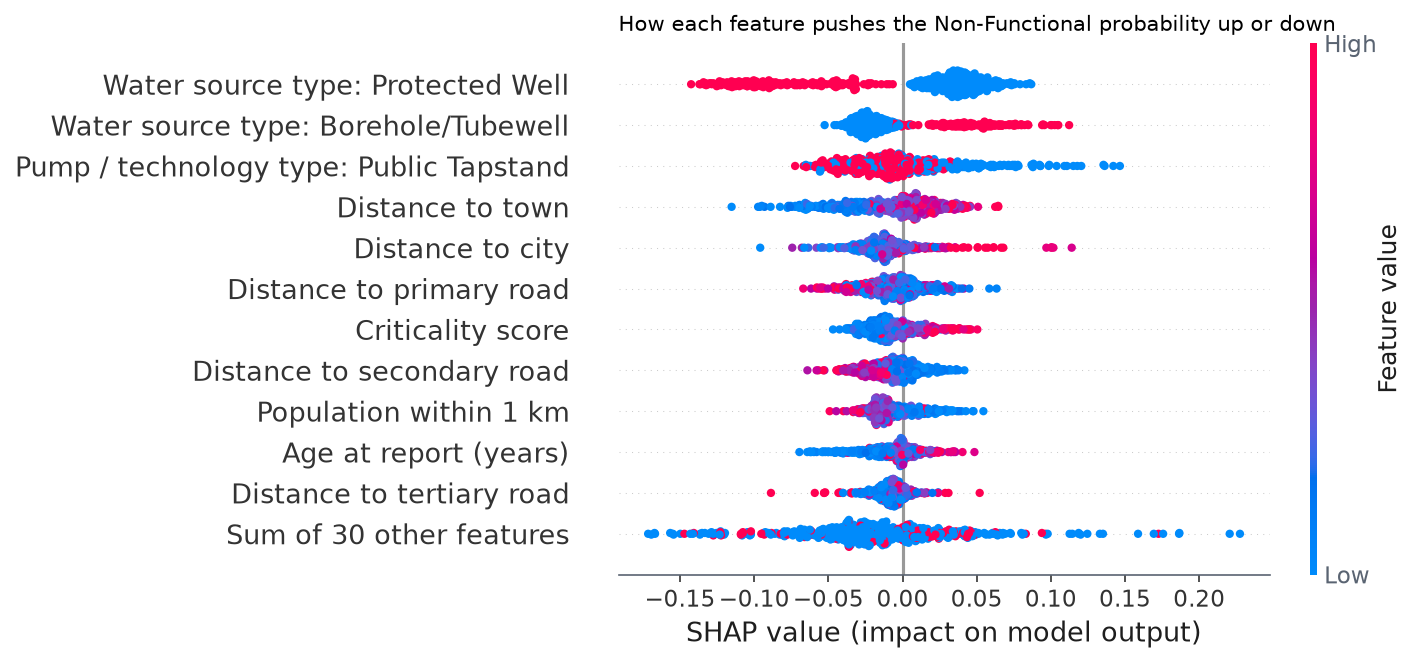

In [5]:
explain.plot_beeswarm_nf(sv, X_t, "reports/figures/shap_beeswarm_non_functional.png")
display(Image("reports/figures/shap_beeswarm_non_functional.png"))

## 3. Local explanations
One broken water point the model caught, and one it missed. Values are shown in their original units (distances in km).

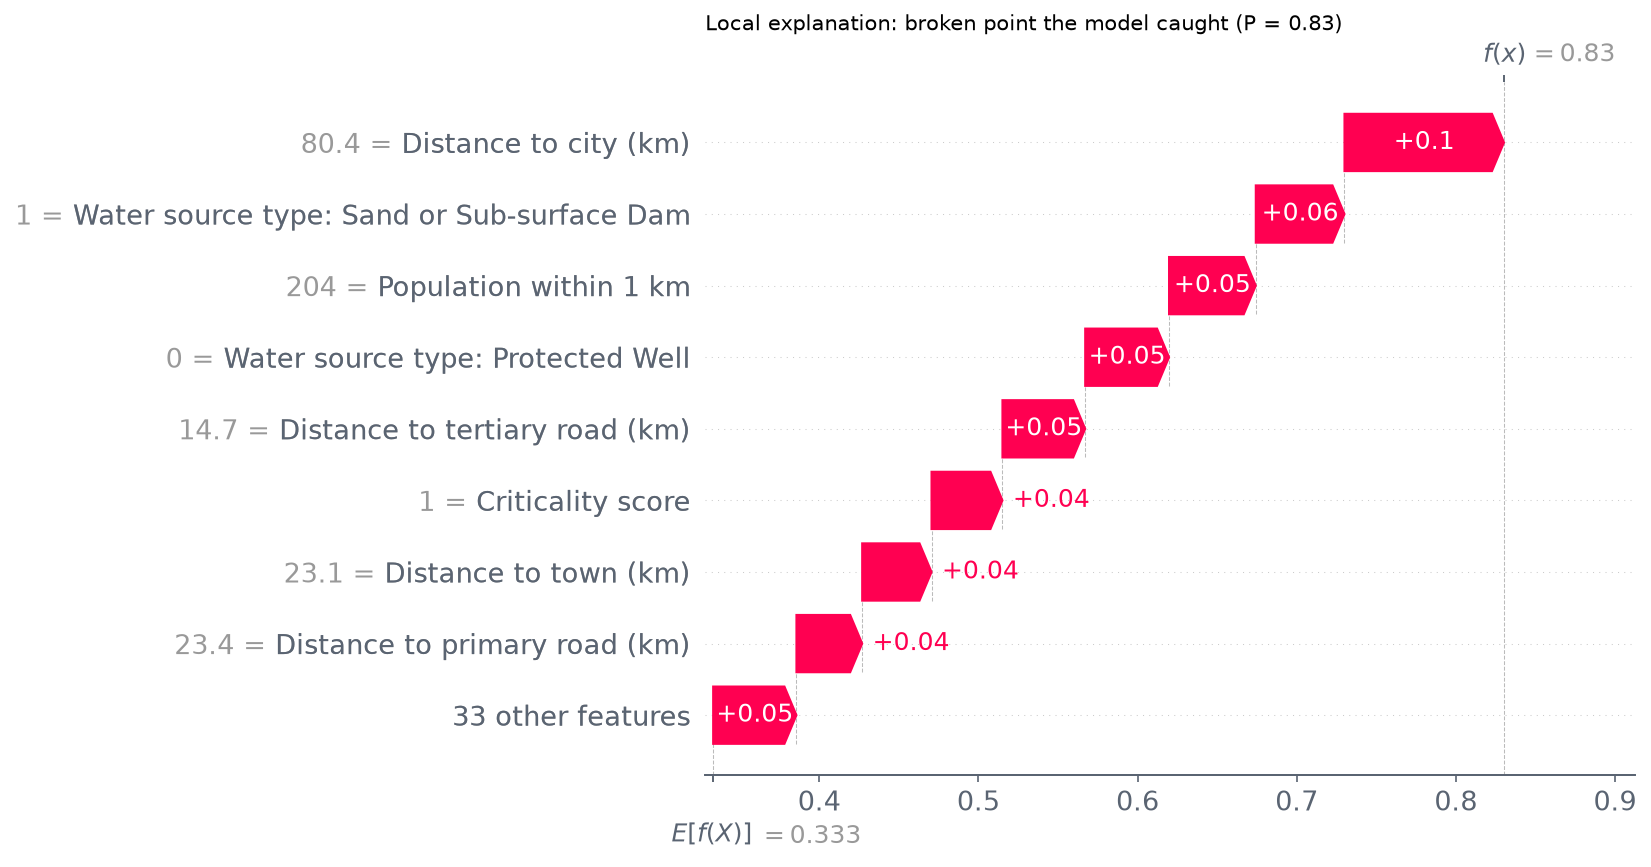

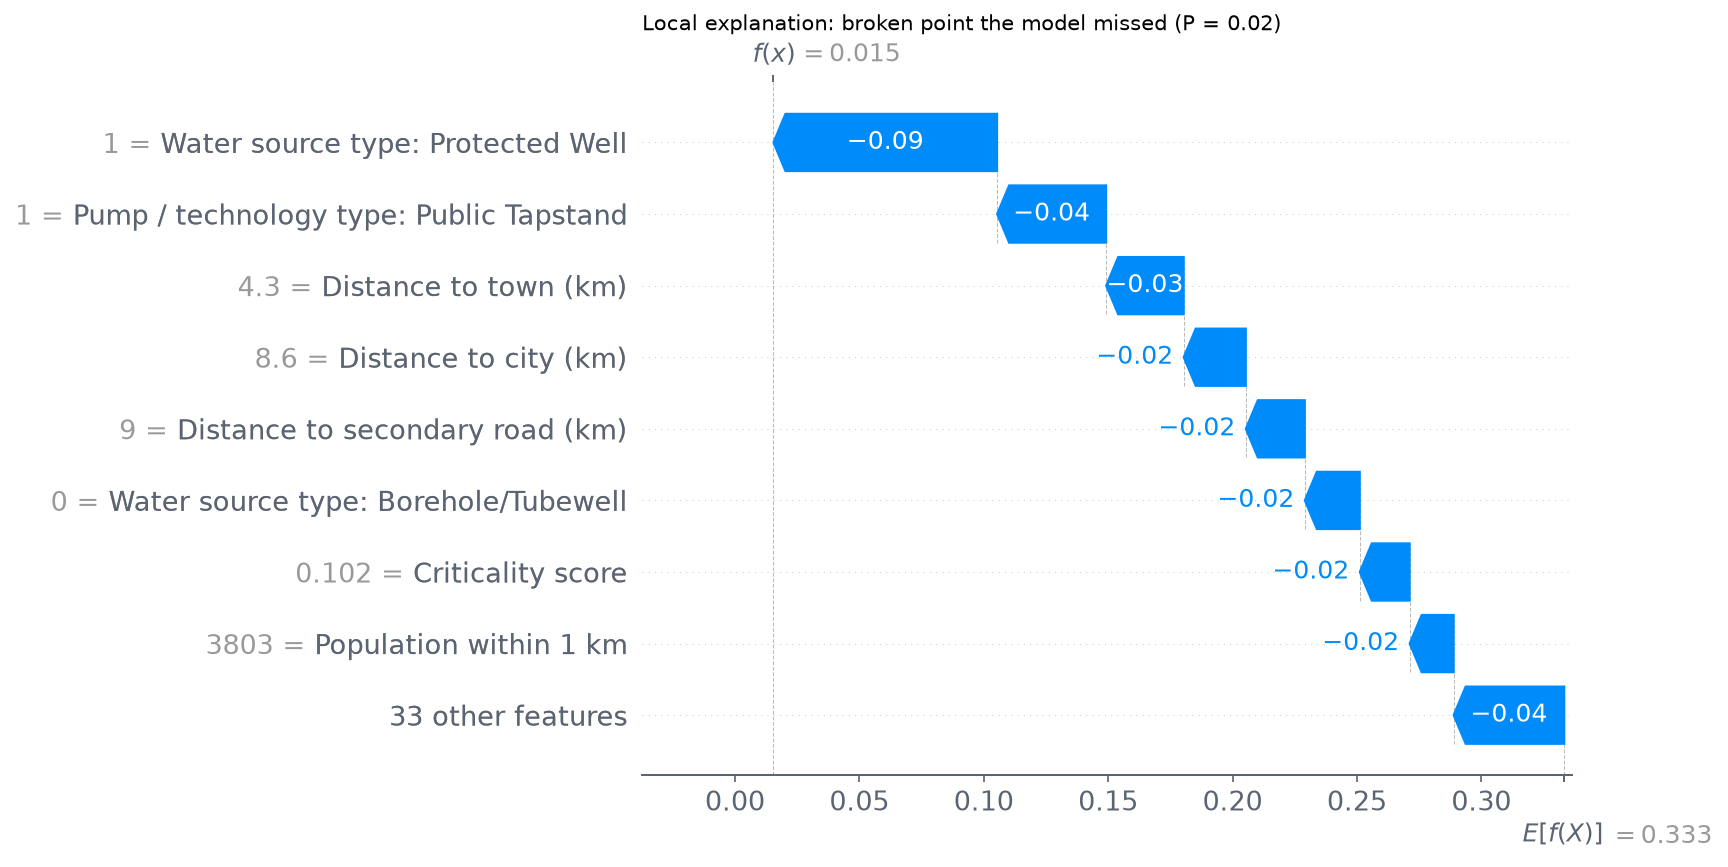

In [6]:
display(Image("reports/figures/shap_local_caught.png"))
display(Image("reports/figures/shap_local_missed.png"))

## 4. Counterfactuals
DiCE searched for changes to the two inputs FundiFix or a water committee can act on (management type and pump type)
that turn a Non-Functional prediction into Functional, for the three test points with the highest Non-Functional probability.

In [7]:
e = json.load(open("reports/metrics/explainability_summary.json"))
rows = [{"water point": cf["water_point"] + 1, "change": f"{k}: {v['from']} -> {v['to']}"}
        for cf in e["counterfactuals"] for k, v in cf["changes"].items()]
pd.DataFrame(rows)

,water point,change
0,1,Pump / technology type: Public Tapstand -> Han...
1,1,Management type: Community Management -> Priva...
2,1,Pump / technology type: Public Tapstand -> Han...
3,1,Pump / technology type: Public Tapstand -> Han...
4,2,Management type: Community Management -> Priva...
5,2,Pump / technology type: Public Tapstand -> Hyd...
6,2,Pump / technology type: Public Tapstand -> Han...
7,2,Pump / technology type: Public Tapstand -> Mot...
8,3,Pump / technology type: Hand Pump - Afridev ->...
9,3,Management type: No Management -> Community Ma...


## 5. What this means for FundiFix
- Water source type and pump technology carry the most signal. Part of this is real (sand dams and some boreholes fail more often),
  and part reflects which organisation surveyed the point: 97% of Public Tapstand records come from the USAID KIWASH survey.
- Distance to roads, towns and cities matters for Non-Functional predictions. Remote points are more often broken,
  which matches FundiFix's experience that travel time delays repairs.
- Age of the water point matters less than expected, partly because installation year is missing for many records.
- Counterfactuals point to management type as the most common lever. They show associations in the data, not proven causes.